In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [94]:
import os
import re
import cv2 # opencv library
import numpy as np
from os.path import isfile, join
import matplotlib.pyplot as plt

In [95]:
col_frames = os.listdir('./Webcam Computer Vision/')
col_frames




['camera0 (1).jpg',
 'camera0 (2).jpg',
 'camera0.jpg',
 'webcam_output_11142022.jpg',
 'webcam_output_11212022.jpg',
 'webcam_output_11212022_1.jpg']

In [96]:
col_images = []

In [97]:
for i in col_frames:
    # read the frames
    img = cv2.imread('./Webcam Computer Vision/'+i)
    # append the frames to the list
    col_images.append(img)

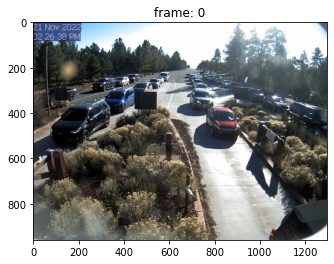

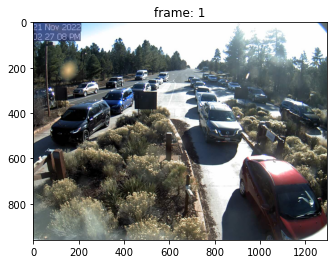

In [98]:
i = 0
for frame in [i, i+1]:
    plt.imshow(cv2.cvtColor(col_images[frame], cv2.COLOR_BGR2RGB))
    plt.title("frame: "+str(frame))
    plt.show()

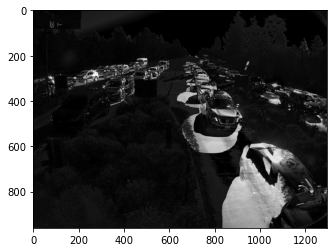

In [99]:
# convert the frames to grayscale
grayA = cv2.cvtColor(col_images[i], cv2.COLOR_BGR2GRAY)
grayB = cv2.cvtColor(col_images[i+1], cv2.COLOR_BGR2GRAY)
#grayC = cv2.cvtColor(col_images[i+1], cv2.COLOR_BGR2GRAY)

#, grayC

# plot the image after frame differencing
plt.imshow(cv2.absdiff(grayB, grayA), cmap = 'gray')
plt.show()

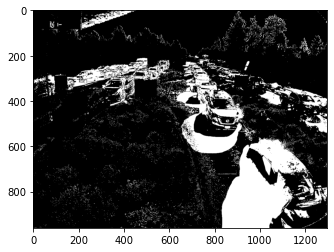

In [100]:
diff_image = cv2.absdiff(grayB, grayA, grayC)

# perform image thresholding
ret, thresh = cv2.threshold(diff_image, 30, 255, cv2.THRESH_BINARY)

# plot image after thresholding
plt.imshow(thresh, cmap = 'gray')
plt.show()

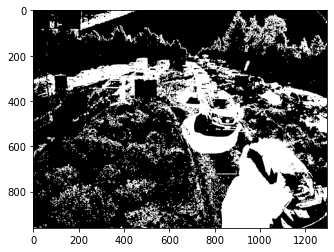

In [101]:
# apply image dilation
kernel = np.ones((3,3),np.uint8)
dilated = cv2.dilate(thresh,kernel,iterations = 1)

# plot dilated image
plt.imshow(dilated, cmap = 'gray')
plt.show()

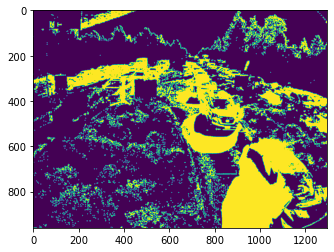

In [102]:
# plot vehicle detection zone
plt.imshow(dilated)
cv2.line(dilated, (0, 80),(256,80),(100, 0, 0))
plt.show()

In [103]:
contours, hierarchy = cv2.findContours(thresh.copy(),cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)


In [104]:
valid_cntrs = []

for i,cntr in enumerate(contours):
    x,y,w,h = cv2.boundingRect(cntr)
    if (x <= 200) & (y >= 80) & (cv2.contourArea(cntr) >= 25):
        valid_cntrs.append(cntr)

# count of discovered contours        
len(valid_cntrs)

13

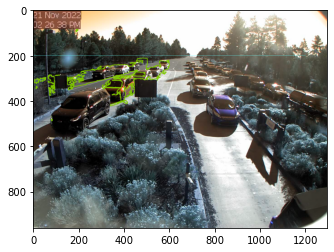

In [105]:
dmy = col_images[0].copy()

cv2.drawContours(dmy, valid_cntrs, -1, (127,200,0), 2)
cv2.line(dmy, (0, 200),(1200,200),(100, 255, 255))
plt.imshow(dmy)
plt.show()